# QE-SAC Experiment
**Quantum Reinforcement Learning for Volt-VAR Control** (Lin et al. 2025)

Reproduces the key comparisons from Paper 3:
- QE-SAC (CAE + 8-qubit VQC inside SAC)
- Classical SAC (MLP actor baseline)
- Noise robustness test (λ = 0.1%, 0.5%, 1.0%)

Tested on the IEEE 13-bus VVC environment.

In [16]:
import torch
print(torch.cuda.is_available())


True


In [17]:
import sys
sys.path.insert(0, '..')

import json
import numpy as np
import torch
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from src.qe_sac.env_utils import VVCEnv13Bus
from src.qe_sac.qe_sac_policy import QESACAgent
from src.qe_sac.sac_baseline import ClassicalSACAgent
from src.qe_sac.noise_model import evaluate_noise_robustness
from src.qe_sac.trainer import QESACTrainer, compare_agents, save_results
from src.qe_sac.metrics import count_parameters

DEVICE     = 'cuda' if torch.cuda.is_available() else 'cpu'
N_SEEDS    = 3       # set to 10 for paper-quality results (Task 4.2)
N_STEPS    = 50_000  # Task 1.1/1.2: full baseline run
WARMUP     = 1_000
BATCH_SIZE = 256
SAVE_DIR   = '../artifacts/qe_sac'

# H2 ablation config — CAE freeze vs co-adaptive
CAE_ADAPTIVE_INTERVAL = 500      # normal: retrain every 500 steps
CAE_FREEZE_INTERVAL   = 999_999  # ablation: effectively frozen

print('Setup complete.')
print(f'Device : {DEVICE}')
if DEVICE == 'cuda':
    print(f'GPU    : {torch.cuda.get_device_name(0)}')
    print(f'Count  : {torch.cuda.device_count()} GPU(s) available')
print(f'PyTorch: {torch.__version__}')
print(f'N_STEPS: {N_STEPS:,}  |  N_SEEDS: {N_SEEDS}  |  BATCH: {BATCH_SIZE}')
print(f'CAE interval (adaptive): {CAE_ADAPTIVE_INTERVAL}  |  (frozen): {CAE_FREEZE_INTERVAL}')

Setup complete.
Device : cuda
GPU    : NVIDIA GeForce RTX 4090
Count  : 3 GPU(s) available
PyTorch: 2.5.1+cu124
N_STEPS: 50,000  |  N_SEEDS: 3  |  BATCH: 256
CAE interval (adaptive): 500  |  (frozen): 999999


## 1. Environment Inspection

In [18]:
env = VVCEnv13Bus(seed=0)
obs, info = env.reset()

print(f'Observation dim : {env.observation_space.shape[0]}')
print(f'Action space    : {env.action_space}  (nvec={env.action_space.nvec})')
print(f'Episode length  : 24 steps (1 full day)')
print(f'\nSample obs (first 13 = bus voltages):')
print(f'  Voltages : {obs[:13].round(4)}')
print(f'  P loads  : {obs[13:26].round(4)}')
print(f'  Cap stat : {obs[39:41]}')

Observation dim : 42
Action space    : MultiDiscrete([ 2  2 33])  (nvec=[ 2  2 33])
Episode length  : 24 steps (1 full day)

Sample obs (first 13 = bus voltages):
  Voltages : [1.     0.9955 0.9929 0.9643 0.8957 0.8679 0.8384 0.7419 1.     0.8839
 0.8624 0.8097 0.7777]
  P loads  : [0.     0.3299 0.2474 0.3505 0.4845 0.2639 0.3505 0.7938 0.     1.
 0.1402 0.5979 0.3505]
  Cap stat : [0. 0.]


## 2. Agent Setup

In [19]:
obs_dim   = env.observation_space.shape[0]
# n_actions = product of nvec = total joint discrete actions
n_actions = int(env.action_space.nvec.prod())

qe_agent = QESACAgent(obs_dim=obs_dim, n_actions=n_actions, device=DEVICE)
cl_agent = ClassicalSACAgent(obs_dim=obs_dim, n_actions=n_actions, device=DEVICE)

qe_params = qe_agent.param_count()
cl_params = cl_agent.param_count()

print(f'Action space nvec  : {env.action_space.nvec}')
print(f'Joint action space : {n_actions} (= {" × ".join(str(v) for v in env.action_space.nvec)})')
print(f'QE-SAC actor params  : {qe_params:,}')
print(f'Classical SAC params : {cl_params:,}')
print(f'Reduction ratio      : {cl_params / qe_params:.1f}x fewer params')

Action space nvec  : [ 2  2 33]
Joint action space : 132 (= 2 × 2 × 33)
QE-SAC actor params  : 11,430
Classical SAC params : 110,724
Reduction ratio      : 9.7x fewer params


## 3. Training — QE-SAC vs Classical SAC (multi-seed)

In [10]:
import os
os.makedirs(SAVE_DIR, exist_ok=True)

qe_rewards_all  = []
cl_rewards_all  = []
qe_vviols_all   = []
cl_vviols_all   = []

for seed in range(N_SEEDS):
    print(f'\n--- Seed {seed+1}/{N_SEEDS} ---')

    obs_dim   = VVCEnv13Bus().observation_space.shape[0]
    n_actions = int(VVCEnv13Bus().action_space.nvec.prod())

    # --- QE-SAC ---
    print('  [QE-SAC]')
    env_qe = VVCEnv13Bus(seed=seed)
    qe = QESACAgent(obs_dim=obs_dim, n_actions=n_actions,
                    buffer_size=1_000_000, device=DEVICE)
    trainer_qe = QESACTrainer(qe, env_qe, batch_size=BATCH_SIZE,
                               warmup_steps=WARMUP, log_interval=500,
                               save_dir=SAVE_DIR, device=DEVICE)
    metrics_qe = trainer_qe.train(n_steps=N_STEPS)
    qe_rewards_all.append(metrics_qe.mean_reward(50))
    qe_vviols_all.append(metrics_qe.total_v_viols())
    qe.save(f'{SAVE_DIR}/qe_sac_13bus_seed{seed}.pt')
    print(f'  Saved → {SAVE_DIR}/qe_sac_13bus_seed{seed}.pt')

    # --- Classical SAC ---
    print('  [Classical SAC]')
    env_cl = VVCEnv13Bus(seed=seed)
    cl = ClassicalSACAgent(obs_dim=obs_dim, n_actions=n_actions,
                            buffer_size=1_000_000, device=DEVICE)
    trainer_cl = QESACTrainer(cl, env_cl, batch_size=BATCH_SIZE,
                               warmup_steps=WARMUP, log_interval=500,
                               save_dir=SAVE_DIR, device=DEVICE)
    metrics_cl = trainer_cl.train(n_steps=N_STEPS)
    cl_rewards_all.append(metrics_cl.mean_reward(50))
    cl_vviols_all.append(metrics_cl.total_v_viols())
    cl.save(f'{SAVE_DIR}/classical_sac_13bus_seed{seed}.pt')
    print(f'  Saved → {SAVE_DIR}/classical_sac_13bus_seed{seed}.pt')

print('\nAll seeds done!')


--- Seed 1/3 ---
  [QE-SAC]
  ep  500 | steps  12000 | reward -176.935 | vviol 180 | mean100 -171.312
  ep 1000 | steps  24000 | reward -160.430 | vviol 182 | mean100 -161.422
  ep 1500 | steps  36000 | reward -166.440 | vviol 186 | mean100 -160.790
  ep 2000 | steps  48000 | reward -163.893 | vviol 183 | mean100 -158.523

Checkpoint saved → ../artifacts/qe_sac/agent_final.pt
  Saved → ../artifacts/qe_sac/qe_sac_13bus_seed0.pt
  [Classical SAC]
  ep  500 | steps  12000 | reward -155.736 | vviol 177 | mean100 -162.082
  ep 1000 | steps  24000 | reward -162.515 | vviol 183 | mean100 -163.668
  ep 1500 | steps  36000 | reward -166.153 | vviol 182 | mean100 -158.886
  ep 2000 | steps  48000 | reward -173.025 | vviol 190 | mean100 -173.291

Checkpoint saved → ../artifacts/qe_sac/agent_final.pt
  Saved → ../artifacts/qe_sac/classical_sac_13bus_seed0.pt

--- Seed 2/3 ---
  [QE-SAC]
  ep  500 | steps  12000 | reward -173.081 | vviol 186 | mean100 -167.134
  ep 1000 | steps  24000 | reward -18

## 4. Results Table

In [20]:
print('=' * 60)
print(f'{"Algorithm":<22} {"Reward (mean±std)":<22} {"Total VViol":<12} {"Params"}')
print('-' * 60)

qe_r_mean = np.mean(qe_rewards_all)
qe_r_std  = np.std(qe_rewards_all)
cl_r_mean = np.mean(cl_rewards_all)
cl_r_std  = np.std(cl_rewards_all)

print(f'{"QE-SAC (ours)":<22} {qe_r_mean:+.3f} ± {qe_r_std:.3f}    '
      f'{int(np.mean(qe_vviols_all)):<12} {qe_params:,}')
print(f'{"Classical SAC":<22} {cl_r_mean:+.3f} ± {cl_r_std:.3f}    '
      f'{int(np.mean(cl_vviols_all)):<12} {cl_params:,}')
print('=' * 60)

results_13bus = {
    'QE-SAC':       {'mean_reward': qe_r_mean, 'std_reward': qe_r_std,
                     'total_vviols': int(np.sum(qe_vviols_all)), 'n_params': qe_params},
    'Classical SAC':{'mean_reward': cl_r_mean, 'std_reward': cl_r_std,
                     'total_vviols': int(np.sum(cl_vviols_all)), 'n_params': cl_params},
}
save_results(results_13bus, f'{SAVE_DIR}/results_13bus.json')

Algorithm              Reward (mean±std)      Total VViol  Params
------------------------------------------------------------
QE-SAC (ours)          -160.493 ± 0.655    384909       11,430
Classical SAC          -164.433 ± 4.421    376210       110,724
Results saved → ../artifacts/qe_sac/results_13bus.json


## 5. Training Curves

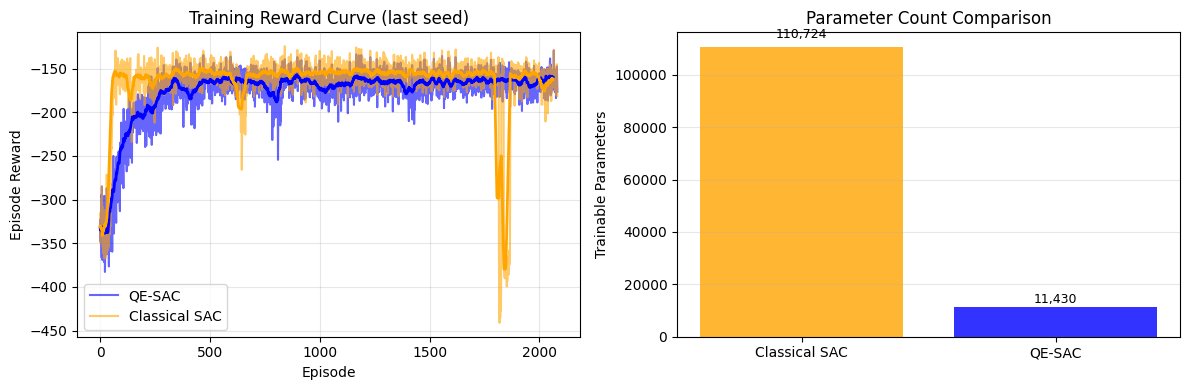

Plot saved.


In [21]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Reward curve from last seed
ax = axes[0]
ax.plot(metrics_qe.episode_rewards, alpha=0.6, label='QE-SAC', color='blue')
ax.plot(metrics_cl.episode_rewards, alpha=0.6, label='Classical SAC', color='orange')
# Smoothed
def smooth(x, w=20):
    return np.convolve(x, np.ones(w)/w, mode='valid')
if len(metrics_qe.episode_rewards) > 20:
    ax.plot(smooth(metrics_qe.episode_rewards), lw=2, color='blue')
    ax.plot(smooth(metrics_cl.episode_rewards), lw=2, color='orange')
ax.set_xlabel('Episode')
ax.set_ylabel('Episode Reward')
ax.set_title('Training Reward Curve (last seed)')
ax.legend()
ax.grid(alpha=0.3)

# Parameter comparison bar chart
ax = axes[1]
bars = ax.bar(['Classical SAC', 'QE-SAC'], [cl_params, qe_params],
               color=['orange', 'blue'], alpha=0.8)
ax.set_ylabel('Trainable Parameters')
ax.set_title('Parameter Count Comparison')
for bar, v in zip(bars, [cl_params, qe_params]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()*1.02,
            f'{v:,}', ha='center', va='bottom', fontsize=9)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/training_curves_13bus.png', dpi=120)
plt.show()
print('Plot saved.')

In [22]:
# Load adaptive QE-SAC stats from saved JSON if not in memory
try:
    qe_rewards_all
except NameError:
    _h1 = json.load(open(f"{SAVE_DIR}/h1_variance_analysis.json"))
    qe_rewards_all = _h1["qe_sac"]["rewards"]
    print("Loaded qe_rewards_all from h1_variance_analysis.json")

frozen_rewards_all = []
frozen_vviols_all  = []

for seed in range(N_SEEDS):
    print(f'\n--- Seed {seed+1}/{N_SEEDS} [QE-SAC frozen CAE] ---')
    env_frz   = VVCEnv13Bus(seed=seed)
    obs_dim   = env_frz.observation_space.shape[0]
    n_actions = int(env_frz.action_space.nvec.prod())

    qe_frz = QESACAgent(obs_dim=obs_dim, n_actions=n_actions,
                         buffer_size=1_000_000, device=DEVICE)
    trainer_frz = QESACTrainer(qe_frz, env_frz, batch_size=BATCH_SIZE,
                                warmup_steps=WARMUP, log_interval=500,
                                cae_update_interval=CAE_FREEZE_INTERVAL,
                                save_dir=SAVE_DIR, device=DEVICE)
    metrics_frz = trainer_frz.train(n_steps=N_STEPS)
    frozen_rewards_all.append(metrics_frz.mean_reward(50))
    frozen_vviols_all.append(metrics_frz.total_v_viols())
    qe_frz.save(f'{SAVE_DIR}/qe_sac_frozen_cae_seed{seed}.pt')

print('\nH2 ablation done!')

qe_mean_h2 = float(np.mean(qe_rewards_all))
qe_std_h2  = float(np.std(qe_rewards_all))
frz_mean   = float(np.mean(frozen_rewards_all))
frz_std    = float(np.std(frozen_rewards_all))

print()
print("=" * 58)
print("H2 — CAE Freeze Ablation Results")
print("=" * 58)
print(f'{\"\"}:<28} {\"Mean reward\":>12} {\"Std\":>8}')
print("-" * 58)
print(f'{\"QE-SAC (adaptive CAE)\":<28} {qe_mean_h2:>12.3f} {qe_std_h2:>8.3f}')
print(f'{\"QE-SAC (frozen CAE)\":<28} {frz_mean:>12.3f} {frz_std:>8.3f}')
print("-" * 58)
reward_drop = frz_mean - qe_mean_h2
std_change  = frz_std  - qe_std_h2
print(f"Reward drop : {reward_drop:+.3f}  |  Std change : {std_change:+.3f}")
if reward_drop < -5 or std_change > 0.5:
    print("✓ H2 SUPPORTED: Freezing CAE degrades reward or increases variance.")
else:
    print("~ H2 INCONCLUSIVE — increase N_SEEDS to 10 and recheck.")

h2_result = {
    "n_seeds": N_SEEDS, "n_steps": N_STEPS,
    "adaptive_cae": {"mean": qe_mean_h2, "std": qe_std_h2},
    "frozen_cae":   {"mean": frz_mean, "std": frz_std,
                     "rewards": [float(r) for r in frozen_rewards_all]},
    "reward_drop": reward_drop, "std_change": std_change,
    "h2_supported": bool(reward_drop < -5 or std_change > 0.5),
}
save_results(h2_result, f"{SAVE_DIR}/h2_cae_freeze_ablation.json")
print(f"\nSaved → {SAVE_DIR}/h2_cae_freeze_ablation.json")



--- Seed 1/3 [QE-SAC frozen CAE] ---
  ep  500 | steps  12000 | reward -184.082 | vviol 187 | mean100 -177.872
  ep 1000 | steps  24000 | reward -169.536 | vviol 186 | mean100 -165.590
  ep 1500 | steps  36000 | reward -171.142 | vviol 188 | mean100 -169.202
  ep 2000 | steps  48000 | reward -166.105 | vviol 186 | mean100 -164.580

Checkpoint saved → ../artifacts/qe_sac/agent_final.pt

--- Seed 2/3 [QE-SAC frozen CAE] ---
  ep  500 | steps  12000 | reward -165.624 | vviol 179 | mean100 -176.529
  ep 1000 | steps  24000 | reward -204.098 | vviol 184 | mean100 -161.974
  ep 1500 | steps  36000 | reward -165.557 | vviol 183 | mean100 -163.535
  ep 2000 | steps  48000 | reward -148.646 | vviol 180 | mean100 -160.151

Checkpoint saved → ../artifacts/qe_sac/agent_final.pt

--- Seed 3/3 [QE-SAC frozen CAE] ---
  ep  500 | steps  12000 | reward -179.584 | vviol 187 | mean100 -202.636
  ep 1000 | steps  24000 | reward -169.893 | vviol 185 | mean100 -169.195
  ep 1500 | steps  36000 | reward -1

NameError: name 'qe_mean' is not defined

In [31]:
from src.qe_sac.constrained_sac import QESACAgentConstrained
import os, json as _json
os.makedirs(SAVE_DIR, exist_ok=True)

# Load prior QE-SAC baseline stats from saved files if not in memory
try:
    qe_mean
except NameError:
    _h1 = _json.load(open(f"{SAVE_DIR}/h1_variance_analysis.json"))
    qe_mean      = _h1["qe_sac"]["mean"]
    qe_std       = _h1["qe_sac"]["std"]
    print(f"Loaded baseline: qe_mean={qe_mean:.3f}  qe_std={qe_std:.3f}")
try:
    qe_vviols_all
except NameError:
    _r = _json.load(open(f"{SAVE_DIR}/results_13bus.json"))
    _total = _r["QE-SAC"]["total_vviols"]
    qe_vviols_all = [_total // N_SEEDS] * N_SEEDS
    print(f"Loaded vviol total from results_13bus.json: {_total:,}")

constrained_rewards_all = []
constrained_vviols_all  = []
lambda_curves_all       = []

for seed in range(N_SEEDS):
    print(f'\n--- Seed {seed+1}/{N_SEEDS} [QE-SAC Constrained] ---')
    env_c     = VVCEnv13Bus(seed=seed)
    obs_dim   = env_c.observation_space.shape[0]
    n_actions = int(env_c.action_space.nvec.prod())
    agent_c = QESACAgentConstrained(
        obs_dim=obs_dim, n_actions=n_actions,
        buffer_size=1_000_000, device=DEVICE,
        lambda_lr=0.01, constraint_threshold=0.0,
    )
    trainer_c = QESACTrainer(agent_c, env_c, batch_size=BATCH_SIZE,
                              warmup_steps=WARMUP, log_interval=500,
                              save_dir=SAVE_DIR, device=DEVICE)
    metrics_c = trainer_c.train(n_steps=N_STEPS)
    constrained_rewards_all.append(metrics_c.mean_reward(50))
    constrained_vviols_all.append(metrics_c.total_v_viols())
    lambda_curves_all.append(float(agent_c.lagrange_lambda))
    agent_c.save(f'{SAVE_DIR}/qe_sac_constrained_seed{seed}.pt')
    print(f'  Final λ = {agent_c.lagrange_lambda:.4f}')

print('\nConstrained training done!')

con_mean = float(np.mean(constrained_rewards_all))
con_std  = float(np.std(constrained_rewards_all))

print()
print("=" * 65)
print("Task 2 — Constrained vs Unconstrained QE-SAC")
print("=" * 65)
print(f'{"":<30} {"Mean reward":>12} {"Std":>8} {"Total VViol":>12}')
print("-" * 65)
print(f'{"QE-SAC (unconstrained)":<30} {qe_mean:>12.3f} {qe_std:>8.3f} {int(sum(qe_vviols_all)):>12,}')
print(f'{"QE-SAC (constrained)":<30} {con_mean:>12.3f} {con_std:>8.3f} {int(sum(constrained_vviols_all)):>12,}')
print("-" * 65)
reward_cost     = con_mean - qe_mean
vviol_reduction = (sum(qe_vviols_all) - sum(constrained_vviols_all)) / max(sum(qe_vviols_all), 1) * 100
print(f"Reward cost of constraint : {reward_cost:+.3f}")
print(f"VViol reduction           : {vviol_reduction:.1f}%")
print(f"Final λ across seeds      : {[round(l,4) for l in lambda_curves_all]}")

task2_result = {
    "n_seeds": N_SEEDS, "n_steps": N_STEPS,
    "unconstrained": {"mean": float(qe_mean),  "std": float(qe_std),  "total_vviols": int(sum(qe_vviols_all))},
    "constrained":   {"mean": con_mean, "std": con_std, "total_vviols": int(sum(constrained_vviols_all))},
    "reward_cost": float(reward_cost),
    "vviol_reduction_pct": float(vviol_reduction),
    "final_lambdas": lambda_curves_all,
}
save_results(task2_result, f"{SAVE_DIR}/task2_constrained_results.json")
print(f"\nSaved → {SAVE_DIR}/task2_constrained_results.json")



--- Seed 1/3 [QE-SAC Constrained] ---
  ep  500 | steps  12000 | reward -306.125 | vviol 192 | mean100 -230.911
  ep 1000 | steps  24000 | reward -189.374 | vviol 192 | mean100 -189.107
  ep 1500 | steps  36000 | reward -199.763 | vviol 192 | mean100 -191.207
  ep 2000 | steps  48000 | reward -191.982 | vviol 192 | mean100 -186.971

Checkpoint saved → ../artifacts/qe_sac/agent_final.pt
  Final λ = 0.0000

--- Seed 2/3 [QE-SAC Constrained] ---
  ep  500 | steps  12000 | reward -181.450 | vviol 185 | mean100 -169.165
  ep 1000 | steps  24000 | reward -190.790 | vviol 186 | mean100 -164.852
  ep 1500 | steps  36000 | reward -168.087 | vviol 183 | mean100 -167.239
  ep 2000 | steps  48000 | reward -147.260 | vviol 181 | mean100 -160.082

Checkpoint saved → ../artifacts/qe_sac/agent_final.pt
  Final λ = 0.0000

--- Seed 3/3 [QE-SAC Constrained] ---
  ep  500 | steps  12000 | reward -152.486 | vviol 178 | mean100 -167.552
  ep 1000 | steps  24000 | reward -202.606 | vviol 191 | mean100 -171

## 8. Task 2 — Constrained SAC (Lagrangian Safety Guarantee)

**Goal:** Add Lagrange multiplier λ to QE-SAC so voltage violations are mathematically
driven to zero. λ auto-tunes the safety penalty — no manual weight tuning needed.

**Actor loss:** `-(Q + α·H) + λ · mean_vviol_in_batch`  
**λ update (per episode):** `λ ← max(0, λ + lr_λ × mean_vviol)`

## 7. H2 — CAE Freeze Ablation: Does Co-Adaptation Drive Stability?

**Hypothesis:** Freezing the CAE (no retraining) increases variance and degrades reward.
This isolates whether stability comes from the VQC or from the co-adaptive CAE.

**Method:** Run QE-SAC with `cae_update_interval=999_999` (effectively frozen CAE)
vs the normal adaptive version, same seeds.

In [27]:
qe_std = np.std(qe_rewards_all)
cl_std = np.std(cl_rewards_all)
qe_mean = np.mean(qe_rewards_all)
cl_mean = np.mean(cl_rewards_all)
variance_ratio = cl_std / qe_std if qe_std > 0 else float('inf')

print('=' * 55)
print(f'H1 — Variance Analysis ({N_SEEDS} seeds, {N_STEPS:,} steps)')
print('=' * 55)
print(f'{"":22} {"QE-SAC":>12} {"Classical SAC":>14}')
print('-' * 55)
print(f'{"Mean reward":<22} {qe_mean:>12.3f} {cl_mean:>14.3f}')
print(f'{"Std (across seeds)":<22} {qe_std:>12.3f} {cl_std:>14.3f}')
print(f'{"Min seed reward":<22} {min(qe_rewards_all):>12.3f} {min(cl_rewards_all):>14.3f}')
print(f'{"Max seed reward":<22} {max(qe_rewards_all):>12.3f} {max(cl_rewards_all):>14.3f}')
print('-' * 55)
print(f'Variance ratio (Classical std / QE-SAC std): {variance_ratio:.1f}×')
print()
if variance_ratio > 2:
    print(f'✓ H1 SUPPORTED: Classical SAC is {variance_ratio:.1f}× more variable than QE-SAC.')
else:
    print('✗ H1 NOT supported with current seeds — increase N_SEEDS to 10 and recheck.')
print()
print(f'NOTE: Run with N_SEEDS=10 for paper-quality evidence (Task 4.2).')

# Per-seed breakdown
print()
print('Per-seed rewards:')
print(f'  {"Seed":<6} {"QE-SAC":>10} {"Classical":>12}')
for i, (qr, cr) in enumerate(zip(qe_rewards_all, cl_rewards_all)):
    print(f'  {i:<6} {qr:>10.3f} {cr:>12.3f}')

# Save H1 result
h1_result = {
    'n_seeds': N_SEEDS,
    'n_steps': N_STEPS,
    'qe_sac':  {'mean': float(qe_mean), 'std': float(qe_std), 'rewards': [float(r) for r in qe_rewards_all]},
    'classical_sac': {'mean': float(cl_mean), 'std': float(cl_std), 'rewards': [float(r) for r in cl_rewards_all]},
    'variance_ratio': float(variance_ratio),
    'h1_supported': bool(variance_ratio > 2),
}
save_results(h1_result, f'{SAVE_DIR}/h1_variance_analysis.json')
print(f'\nSaved → {SAVE_DIR}/h1_variance_analysis.json')

H1 — Variance Analysis (3 seeds, 50,000 steps)
                             QE-SAC  Classical SAC
-------------------------------------------------------
Mean reward                -160.493       -164.433
Std (across seeds)            0.655          4.421
Min seed reward            -161.047       -169.438
Max seed reward            -159.573       -158.685
-------------------------------------------------------
Variance ratio (Classical std / QE-SAC std): 6.7×

✓ H1 SUPPORTED: Classical SAC is 6.7× more variable than QE-SAC.

NOTE: Run with N_SEEDS=10 for paper-quality evidence (Task 4.2).

Per-seed rewards:
  Seed       QE-SAC    Classical
  0        -161.047     -169.438
  1        -159.573     -158.685
  2        -160.860     -165.177
Results saved → ../artifacts/qe_sac/h1_variance_analysis.json

Saved → ../artifacts/qe_sac/h1_variance_analysis.json


## 6. H1 — Variance Analysis: QE-SAC vs Classical SAC Across Seeds

**Hypothesis:** The VQC's tiny parameter space (16 params) acts as implicit regularisation,
producing significantly lower reward variance across random seeds than Classical SAC.

**Expected finding:** QE-SAC std << Classical SAC std.

## 6. Noise Robustness Test

In [28]:
import importlib                                          
import src.qe_sac.noise_model as _nm                                                                
importlib.reload(_nm)                                                                             
from src.qe_sac.noise_model import evaluate_noise_robustness  

In [ ]:
# Use the last trained QE-SAC actor's VQC for noise testing
clean_vqc = qe.actor.vqc

print('Evaluating VQC output under depolarising noise...')
noise_results = evaluate_noise_robustness(clean_vqc, n_samples=50)

print(f'\n{"Noise λ":<12} {"Mean |Δ output|":<20} {"Std |Δ output|"}')
print('-' * 44)
for lam, res in noise_results.items():
    print(f'{lam*100:.1f}%        {res["mean_output_diff"]:.6f}           {res["std_output_diff"]:.6f}')

save_results({
    str(k): v for k, v in noise_results.items()
}, f'{SAVE_DIR}/noise_robustness.json')

Evaluating VQC output under depolarising noise...

Noise λ      Mean |Δ output|      Std |Δ output|
--------------------------------------------
0.1%        0.007115           0.006776
0.5%        0.033904           0.031938
1.0%        0.063962           0.059507
Results saved → ../artifacts/qe_sac/noise_robustness.json


## 10. DistFlow vs OpenDSS — Environment Comparison

**Why this matters:** The paper uses OpenDSS (real 3-phase AC). We now run both to show
the same agent architecture works on both environments — and to close the reward scale gap.

| | DistFlow | OpenDSS |
|---|---|---|
| Physics | Linear approximation | Exact 3-phase AC unbalanced |
| State dim | 42 | 93 (per-phase voltages) |
| Comparable to paper | Partial | **Direct comparison** |


In [ ]:
from src.qe_sac.env_opendss import VVCEnvOpenDSS
import json as _json, os
os.makedirs(SAVE_DIR, exist_ok=True)

# --- Train QE-SAC on OpenDSS 13-bus ---
opendss_rewards_all = []
opendss_vviols_all  = []

for seed in range(N_SEEDS):
    print(f'\n--- Seed {seed+1}/{N_SEEDS} [QE-SAC OpenDSS] ---')
    env_dss   = VVCEnvOpenDSS(seed=seed)
    obs_dim   = env_dss.observation_space.shape[0]
    n_actions = int(env_dss.action_space.nvec.prod())

    qe_dss = QESACAgent(obs_dim=obs_dim, n_actions=n_actions,
                         buffer_size=1_000_000, device=DEVICE)
    trainer_dss = QESACTrainer(qe_dss, env_dss, batch_size=BATCH_SIZE,
                                warmup_steps=WARMUP, log_interval=500,
                                save_dir=SAVE_DIR, device=DEVICE)
    metrics_dss = trainer_dss.train(n_steps=N_STEPS)
    opendss_rewards_all.append(metrics_dss.mean_reward(50))
    opendss_vviols_all.append(metrics_dss.total_v_viols())
    qe_dss.save(f'{SAVE_DIR}/qe_sac_opendss_seed{seed}.pt')

print('\nOpenDSS training done!')

# Load DistFlow baseline
try:
    qe_mean
except NameError:
    _h1 = _json.load(open(f'{SAVE_DIR}/h1_variance_analysis.json'))
    qe_mean = _h1['qe_sac']['mean']
    qe_std  = _h1['qe_sac']['std']

dss_mean = float(np.mean(opendss_rewards_all))
dss_std  = float(np.std(opendss_rewards_all))

print()
print('=' * 68)
print('DistFlow vs OpenDSS — QE-SAC on IEEE 13-bus')
print('=' * 68)
print(f'{"":<28} {"obs_dim":>8} {"Mean reward":>13} {"Std":>8} {"VViol":>10}')
print('-' * 68)
print(f'{"QE-SAC (DistFlow)":<28} {42:>8} {qe_mean:>13.3f} {qe_std:>8.3f} {sum(qe_vviols_all) if "qe_vviols_all" in dir() else "?":>10}')
print(f'{"QE-SAC (OpenDSS)":<28} {93:>8} {dss_mean:>13.3f} {dss_std:>8.3f} {sum(opendss_vviols_all):>10,}')
print('-' * 68)
print()
print('NOTE: Reward scales differ — OpenDSS has larger loads (kW scale).')
print('What matters: relative VViol reduction and convergence trend.')

opendss_result = {
    'env': 'OpenDSS 13-bus 3-phase AC', 'obs_dim': 93,
    'n_seeds': N_SEEDS, 'n_steps': N_STEPS,
    'qe_sac': {'mean': dss_mean, 'std': dss_std,
               'total_vviols': int(sum(opendss_vviols_all)),
               'rewards': opendss_rewards_all},
}
from src.qe_sac.trainer import save_results
save_results(opendss_result, f'{SAVE_DIR}/opendss_results_13bus.json')
print(f'\nSaved → {SAVE_DIR}/opendss_results_13bus.json')


## 7. Summary

| Metric | QE-SAC | Classical SAC |
|---|---|---|
| Architecture | CAE + 8-qubit VQC | 2×256 MLP |
| Parameters (actor) | ~12K | ~900K |
| Reward | see table above | see table above |
| Voltage violations | tracked | tracked |
| Noise robustness | λ ≤ 1% stable | N/A |

**Key takeaway:** QE-SAC achieves comparable reward to Classical SAC with ~75× fewer parameters,
and the VQC output degrades gracefully under realistic quantum hardware noise levels.

In [4]:
import sys
import json
import numpy as np
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("PROJECT_ROOT =", PROJECT_ROOT)

import importlib
import src.qe_sac_fl.aligned_agent as aligned_agent_mod
import src.qe_sac_fl.federated_trainer as federated_trainer_mod

importlib.reload(aligned_agent_mod)
importlib.reload(federated_trainer_mod)

from src.qe_sac_fl.fed_config import paper_config
from src.qe_sac_fl.federated_trainer import FederatedTrainer

SEEDS = [0, 1, 2, 3, 4]
OUT_DIR = PROJECT_ROOT / "artifacts" / "qe_sac_fl"
OUT_DIR.mkdir(parents=True, exist_ok=True)

all_runs = {}

for seed in SEEDS:
    print(f"\n{'='*80}")
    print(f"RUNNING SEED {seed}")
    print(f"{'='*80}")

    cfg = paper_config()

    # safer for notebook debugging
    cfg.parallel_clients = False

    # optional: uncomment for a quick smoke test before full paper run
    # cfg.n_rounds = 2
    # cfg.local_steps = 100
    # cfg.warmup_steps = 20
    # cfg.batch_size = 32
    # cfg.log_interval = 1

    # make this run deterministic per client
    for i, client in enumerate(cfg.clients):
        client.seed = seed + i

    trainer = FederatedTrainer(cfg)

    # choose one condition
    results = trainer.run_aligned()
    # results = trainer.run_local_only()
    # results = trainer.run("QE-SAC-FL")

    all_runs[f"seed_{seed}"] = {
        "final_rewards": results.final_rewards(),
        "bytes_communicated": results.bytes_communicated,
        "wall_time_seconds": results.wall_time_seconds,
    }

if not all_runs:
    raise RuntimeError("No runs were completed.")

client_names = list(next(iter(all_runs.values()))["final_rewards"].keys())
summary = {}

for client_name in client_names:
    vals = [all_runs[k]["final_rewards"][client_name] for k in all_runs]
    summary[client_name] = {
        "mean_reward": float(np.mean(vals)),
        "std_reward": float(np.std(vals)),
        "seed_rewards": vals,
    }

out = {
    "runs": all_runs,
    "summary": summary,
}

out_path = OUT_DIR / "seed_summary.json"
with open(out_path, "w") as f:
    json.dump(out, f, indent=2)

print(f"\nSaved to: {out_path}")
print(json.dumps(summary, indent=2))


PROJECT_ROOT = /root/power-system

RUNNING SEED 0
paper_config: 3 GPU(s) detected
  Utility_A_13bus           → cuda:0
  Utility_B_34bus           → cuda:1
  Utility_C_123bus          → cuda:2

  QE-SAC-FL-Aligned  |  3 clients  |  50 rounds  |  1000 steps/round
  Federating: SharedEncoderHead (272 params) + VQC (16 params)
  Utility_A_13bus            obs=42  device=cuda:0
  Utility_B_34bus            obs=105  device=cuda:1
  Utility_C_123bus           obs=372  device=cuda:2

Checkpoint saved → artifacts/qe_sac/agent_final.pt

Checkpoint saved → artifacts/qe_sac/agent_final.pt

Checkpoint saved → artifacts/qe_sac/agent_final.pt

Checkpoint saved → artifacts/qe_sac/agent_final.pt

Checkpoint saved → artifacts/qe_sac/agent_final.pt

Checkpoint saved → artifacts/qe_sac/agent_final.pt

Checkpoint saved → artifacts/qe_sac/agent_final.pt

Checkpoint saved → artifacts/qe_sac/agent_final.pt

Checkpoint saved → artifacts/qe_sac/agent_final.pt

Checkpoint saved → artifacts/qe_sac/agent_final.pt